In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 2** - Mystery ML model

- Model takes two numbers as input and returns a log-likelihood score.
  - **Goal** - maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.

- **Method of tackling this problem** - Bayesian optimisation, which selects the next inputs based on what it has learned so far.
  - I will aim to balance exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

- **Process and thinking** - use probability of improvement (PI) to exploit the area around our current best discovery.


In [14]:
X = np.load(r'/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy')
Y = np.load(r'/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy')

In [15]:
# New data from Week 3 (Function 2)
X_w3_new_point = np.array([0.998312, 0.002851], dtype=np.float64)
Y_w3_new_point = np.array([-0.08088785665400462], dtype=np.float64)

# Append the new data points
X_updated = np.vstack((X, X_w3_new_point.reshape(1, -1)))
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)
Y_updated = np.append(Y, Y_w3_new_point)[unique_indices]

# Save the updated arrays
np.save(r'/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy', X_unique)
np.save(r'/Users/pratham/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy', Y_updated)

In [16]:
# Show updated arrays
print("Updated Inputs (X) - Function 2: ", X_unique)
print("Updated Outputs (Y) - Function 2: ", Y_updated)

Updated Inputs (X) - Function 2:  [[0.14269907 0.34900513]
 [0.33864816 0.21386725]
 [0.34174959 0.02869772]
 [0.43816606 0.68501826]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.638512   0.01429   ]
 [0.66579958 0.12396913]
 [0.70263656 0.9265642 ]
 [0.84527543 0.71112027]
 [0.87779099 0.7786275 ]
 [0.998312   0.002851  ]]
Updated Outputs (Y) - Function 2:  [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.53899612  0.61120522  0.29399291  0.42058624 -0.08088786]


### **Interpreation of the Output and Potential Next steps to improve the model**


- We have found a region with low probability - output = 0.297.
  - In a log-likelihood context, this is a pretty weak starting point that hasn't yet reached near a local or global peak.

- What this means for the next step is that we need to move away from the random search strategy that I went for in Week 1 to a more strategic Gaussian Process Model with a Expected Improvement (EI) surrogate model, as breifly outlined in week 1 strategic approach.
  - By using this surrogate model we can map out which point is strategically going to help us find a global and local optimum, rather than a random search which wasn't very useful.


### **Bayesian Optimisation** - Gaussian Processess using RBF kernel


- Initially I am sticking with the RBF kernel, as it often works better for smaller deminsional functions.
  - I believe that if the RBF kernel doesn't work as well as I expect it to work I will swtich to a Mattern kerenel however, I know that Matern is usually better of in a 4D+ scenario.

- I create a noise assumption which is a standard 0.01 and I will play around with this as we move forward in the exploration stages.


In [17]:
noise_assumption = 0.01

In [18]:
kernel = RBF(length_scale=1.0)
model = GaussianProcessRegressor(
    kernel = kernel,
    alpha = noise_assumption,
    n_restarts_optimizer= 10,
)
model.fit(X_unique, Y_updated)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",RBF(length_scale=1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.01
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",10
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `."

### **Acquisition Function** - Probability of Improvement

- I am using Probability of improvement as this is a function which is a mystery ML model which returns log-likelihood score which is often noisy and prone to trapping optimizers in local optima.
  - The PI can help the search jump out of a local peak if the surrounding uncertainty suggests a higher probability of finding a better point elsewhere.

- Additionally, PI helps use the Gaussian Process's predictive mean and variance to quanitfy the utility of a point before evaluating it.

- Additioanlly since this is only a 2D function, once a region of the global maximum is identified, PI can refine the solution by targetting the exact coordinates most likley to provide incremental improvement to the log-likelihood.


In [20]:
def probability_of_improvement(X_unique, model, y_max, eta=0.05):
    mu, sigma = model.predict(X_unique, return_std=True)
    mu = mu.reshape(-1,1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        z = (mu - y_max - eta) / sigma
        pi = norm.cdf(z)
        pi[sigma == 0.0] = 0.0
        
    return pi.ravel()

y_max = np.max(Y_updated)

# Creating 10,000 points to enhance the 2D grid search
x_grid = np.random.uniform(0, 1, size=(30000, 2))

# Evaluate the acquisition function at these points
pi_values = probability_of_improvement(x_grid, model, y_max, eta=0.05)

# Identify the point with the highest improvements
best_idx = np.argmax(pi_values)
next_query = x_grid[best_idx]

print(f"Strategic Week 3 Query (Function 2): [{next_query[0]:.6f}, {next_query[1]:.6f}]")

Strategic Week 3 Query (Function 2): [0.871256, 0.999348]


### **Visualisation of the Model**

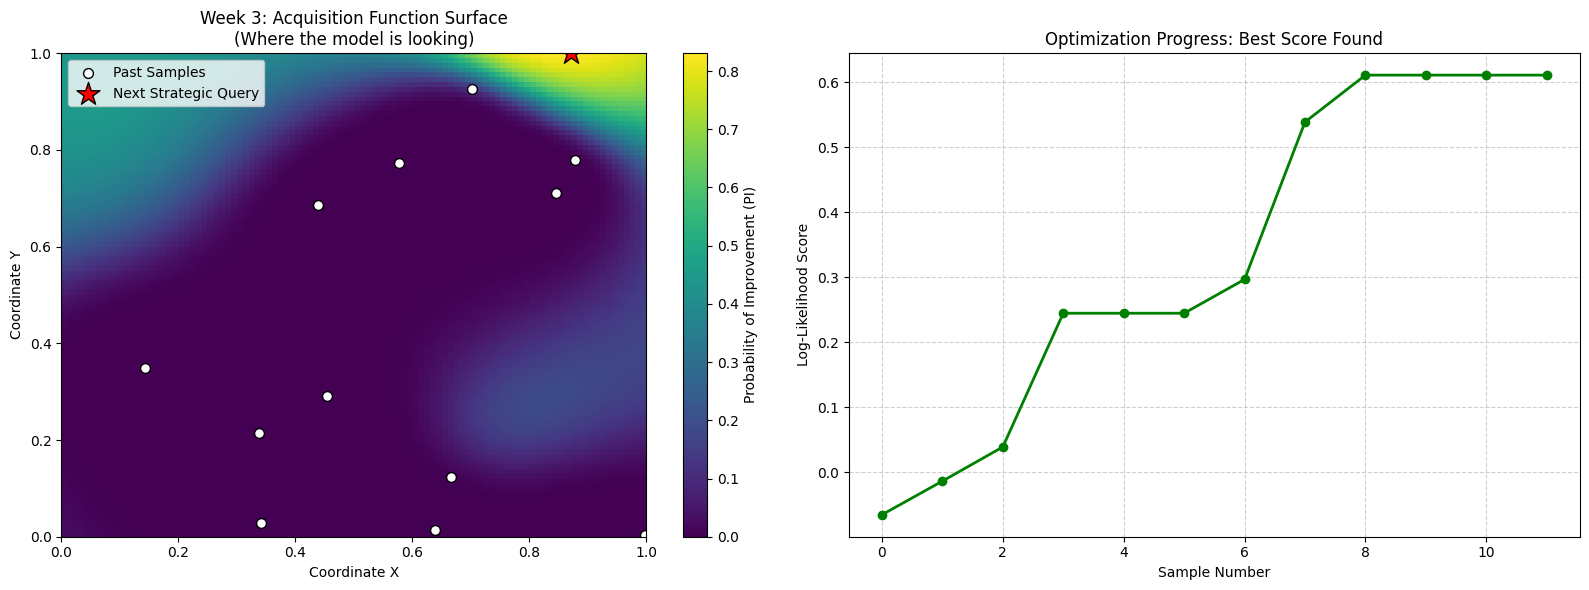

Strategic Week 3 Result: Next point to query is at (0.871256, 0.999348)


In [21]:
import matplotlib.pyplot as plt

# 1. Create a dense grid for a smooth visualization
res = 100
x1 = np.linspace(0, 1, res)
x2 = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(x1, x2)
X_plot = np.vstack([X1.ravel(), X2.ravel()]).T

# 2. Calculate PI values across the entire grid
pi_plot = probability_of_improvement(X_plot, model, y_max, eta=0.05)
PI_grid = pi_plot.reshape(res, res)

# 3. Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: The Probability of Improvement Heatmap
sc = ax1.imshow(PI_grid, extent=[0, 1, 0, 1], origin='lower', cmap='viridis', aspect='auto')
cbar = plt.colorbar(sc, ax=ax1, label='Probability of Improvement (PI)')

# Overlay past samples
ax1.scatter(X_unique[:, 0], X_unique[:, 1], c='white', edgecolors='black', marker='o', s=50, label='Past Samples')

# Highlight the next recommended query point
ax1.scatter(next_query[0], next_query[1], c='red', marker='*', s=300, edgecolors='black', label='Next Strategic Query')

ax1.set_title('Week 3: Acquisition Function Surface\n(Where the model is looking)')
ax1.set_xlabel('Coordinate X')
ax1.set_ylabel('Coordinate Y')
ax1.legend()

# Subplot 2: Progress Tracker (Optimization Path)
running_max = np.maximum.accumulate(Y_updated)
ax2.plot(running_max, marker='o', linestyle='-', color='green', linewidth=2)
ax2.set_title('Optimization Progress: Best Score Found')
ax2.set_xlabel('Sample Number')
ax2.set_ylabel('Log-Likelihood Score')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Strategic Week 3 Result: Next point to query is at ({next_query[0]:.6f}, {next_query[1]:.6f})")